# Brain MRI Tissue Segmentation — Multi-Class Semantic Segmentation
## FCN (Fully Convolutional Network) | 4-Class (Background / CSF / Grey Matter / White Matter) | MRBrainS18 Dataset

**Dataset:** MRBrainS18 Challenge Dataset — 7 labeled training subjects, multi-sequence MRI (T1, FLAIR, IR). Only the `training` split is used since the `test` split has no publicly released segmentation labels.

**Label Remapping:** MRBrainS18 uses 9 classes which are consolidated into 4 tissue classes:
- 0 → Background
- 1, 2, 8 → Grey Matter (cortical GM + basal ganglia + brainstem/cerebellum)
- 3, 4 → White Matter (WM + WM lesions)
- 5, 6, 7 → CSF (ventricular CSF + vessels + external CSF)

**Training Notes:**
- Only 7 labeled subjects are available; therefore, every slice (`step=1`) is used to maximize the training dataset.
- Strong data augmentation is applied to improve model generalization.
- EarlyStopping is disabled so the model trains for the full configured number of epochs.

## 1. Import Libraries

In [2]:
import os
import cv2
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (
    Input, Conv2D, UpSampling2D, concatenate,
    BatchNormalization, Dropout, Activation
)
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Conv2DTranspose, Add
from tensorflow.keras import callbacks
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import time
import datetime

!pip install nibabel -q
import nibabel as nib

print('TensorFlow version:', tf.__version__)
print('GPUs available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

In [3]:
# ─── Paths ────────────────────────────────────────────────────────────────────
TRAIN_ROOT = '/kaggle/input/datasets/maheswarimudadla/training/training'
# Note: test split excluded — no public segmentation labels available

PROCESSED_DIR  = 'mrbrains_processed'
IMAGE_FOLDER   = os.path.join(PROCESSED_DIR, 'images')
MASK_FOLDER    = os.path.join(PROCESSED_DIR, 'masks')
TRAIN_IMG_DIR  = os.path.join(PROCESSED_DIR, 'train', 'images')
TRAIN_MASK_DIR = os.path.join(PROCESSED_DIR, 'train', 'masks')
TEST_IMG_DIR   = os.path.join(PROCESSED_DIR, 'test',  'images')
TEST_MASK_DIR  = os.path.join(PROCESSED_DIR, 'test',  'masks')

# ─── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 8    # smaller batch — fewer total slices than OASIS/IBSR
EPOCHS      = 100
SEED        = 42
TEST_SPLIT  = 0.20  # slightly larger test split given small dataset
NUM_CLASSES = 4
CLASS_NAMES = ['Background', 'CSF', 'Grey Matter', 'White Matter']

# ─── MRBrainS18 label remapping ───────────────────────────────────────────────
# Original 9 classes → 4 standard tissue classes (matches OASIS-1 and IBSR)
MRBRAINS_REMAP = {
    0: 0,  # Background
    1: 2,  # Cortical Grey Matter → GM
    2: 2,  # Basal Ganglia → GM
    3: 3,  # White Matter → WM
    4: 3,  # White Matter Lesions → WM
    5: 1,  # Ventricular CSF → CSF
    6: 1,  # Vessels/Choroid Plexus → CSF
    7: 1,  # External CSF/Sulci → CSF
    8: 2,  # Brainstem + Cerebellum → GM
}

print('Config set ✓')
print('Label remapping:', MRBRAINS_REMAP)

Config set ✓
Label remapping: {0: 0, 1: 2, 2: 2, 3: 3, 4: 3, 5: 1, 6: 1, 7: 1, 8: 2}


## 3. Extract 2D Slices — Remap 9 Classes to 4

In [4]:
for d in [IMAGE_FOLDER, MASK_FOLDER,
          TRAIN_IMG_DIR, TRAIN_MASK_DIR,
          TEST_IMG_DIR,  TEST_MASK_DIR]:
    os.makedirs(d, exist_ok=True)

print('Directories ready ✓')

Directories ready ✓


In [5]:
import os
import shutil
import cv2
import nibabel as nib
import numpy as np
from tqdm import tqdm


def normalize_slice(arr):
    mn, mx = arr.min(), arr.max()
    if mx - mn == 0:
        return np.zeros_like(arr, dtype=np.uint8)
    return ((arr - mn) / (mx - mn) * 255).astype(np.uint8)


def remap_labels(seg_arr, remap_dict):
    """Remap integer label array using a dictionary mapping."""
    out = np.zeros_like(seg_arr, dtype=np.uint8)
    for orig_label, new_label in remap_dict.items():
        out[seg_arr == orig_label] = new_label
    return out


def extract_slices_mrbrains(subject_dir, subject_name, img_out, mask_out, step=1):
    """
    Extract aligned T1 and segmentation slices from MRBrainS18.

    Uses reg_T1.nii because it is already registered to segm.nii.
    Both volumes have shape (240, 240, 48).
    """

    # Candidate paths for registered T1
    t1_candidates = [
        os.path.join(subject_dir, "orig", "reg_T1.nii"),
        os.path.join(subject_dir, "orig", "reg_T1.nii.gz"),
        os.path.join(subject_dir, "pre", "reg_T1.nii"),
        os.path.join(subject_dir, "pre", "reg_T1.nii.gz"),
    ]

    t1_path = None
    for p in t1_candidates:
        if os.path.exists(p):
            t1_path = p
            break

    # Segmentation
    seg_candidates = [
        os.path.join(subject_dir, "segm.nii"),
        os.path.join(subject_dir, "segm.nii.gz"),
    ]

    seg_path = None
    for p in seg_candidates:
        if os.path.exists(p):
            seg_path = p
            break

    if t1_path is None or seg_path is None:
        print(f"Skipping {subject_name} (missing reg_T1 or segm)")
        return 0

    # Load volumes
    brain_vol = np.squeeze(nib.load(t1_path).get_fdata())
    seg_vol = np.squeeze(nib.load(seg_path).get_fdata())

    print(f"{subject_name}")
    print(f"  T1 : {brain_vol.shape}")
    print(f"  Seg: {seg_vol.shape}")

    # Safety check
    if brain_vol.shape != seg_vol.shape:
        print(f"Shape mismatch in {subject_name}, skipping.")
        return 0

    saved = 0

    for i in range(0, brain_vol.shape[2], step):

        brain_slice = brain_vol[:, :, i]
        seg_slice = seg_vol[:, :, i]

        # Skip completely empty MRI slices
        if np.max(brain_slice) == 0:
            continue

        img_arr = normalize_slice(brain_slice)

        mask_arr = remap_labels(
            np.round(seg_slice).astype(np.uint8),
            MRBRAINS_REMAP
        )

        filename = f"{subject_name}_sl{i:03d}.png"

        cv2.imwrite(
            os.path.join(img_out, filename),
            img_arr
        )

        cv2.imwrite(
            os.path.join(mask_out, filename),
            mask_arr
        )

        saved += 1

    return saved


# ---------------------------------------------------------
# Remove previous extracted dataset
# ---------------------------------------------------------

for folder in [IMAGE_FOLDER, MASK_FOLDER]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder, exist_ok=True)


# ---------------------------------------------------------
# Extract slices from all training subjects
# ---------------------------------------------------------

subject_folders = sorted([
    d for d in os.listdir(TRAIN_ROOT)
    if os.path.isdir(os.path.join(TRAIN_ROOT, d))
])

print(f"Found {len(subject_folders)} training subjects:")
print(subject_folders)
print()

total_slices = 0

for subj_name in tqdm(subject_folders, desc="Extracting slices"):

    subj_dir = os.path.join(TRAIN_ROOT, subj_name)

    total_slices += extract_slices_mrbrains(
        subj_dir,
        subj_name,
        IMAGE_FOLDER,
        MASK_FOLDER,
        step=1
    )

print("\nExtraction Complete!")
print(f"Total slices extracted : {total_slices}")
print(f"Images saved           : {len(os.listdir(IMAGE_FOLDER))}")
print(f"Masks saved            : {len(os.listdir(MASK_FOLDER))}")

Found 7 training subjects:
['1', '14', '27', '29', '4', '5', '7']



Extracting slices:   0%|          | 0/7 [00:00<?, ?it/s]

1
  T1 : (240, 240, 48)
  Seg: (240, 240, 48)


Extracting slices:  29%|██▊       | 2/7 [00:00<00:01,  4.57it/s]

14
  T1 : (240, 240, 48)
  Seg: (240, 240, 48)


...

4
  T1 : (240, 240, 48)
  Seg: (240, 240, 48)


Extracting slices:  86%|████████▌ | 6/7 [00:01<00:00,  4.11it/s]

5
  T1 : (240, 240, 48)
  Seg: (240, 240, 48)


Extracting slices: 100%|██████████| 7/7 [00:01<00:00,  3.96it/s]

7
  T1 : (240, 240, 48)
  Seg: (240, 240, 48)

Extraction Complete!
Total slices extracted : 336
Images saved           : 336
Masks saved            : 336


## 4. Verify Label Remapping & Visualize

In [6]:
sample_mask_files = random.sample(os.listdir(MASK_FOLDER), min(20, len(os.listdir(MASK_FOLDER))))
all_vals = set()
for f in sample_mask_files:
    m = cv2.imread(os.path.join(MASK_FOLDER, f), cv2.IMREAD_GRAYSCALE)
    all_vals.update(np.unique(m).tolist())

print('Unique label values found across sample masks:', sorted(all_vals))
print('Expected: [0, 1, 2, 3]  (Background, CSF, Grey Matter, White Matter)')

Unique label values found across sample masks: [0, 1, 2, 3]
Expected: [0, 1, 2, 3]  (Background, CSF, Grey Matter, White Matter)


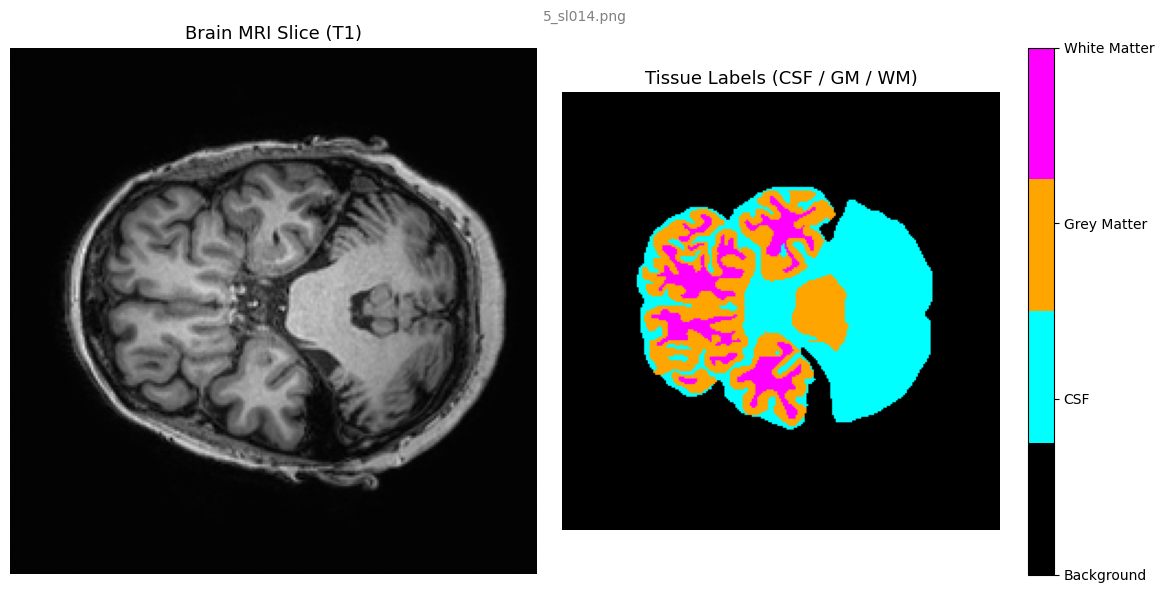

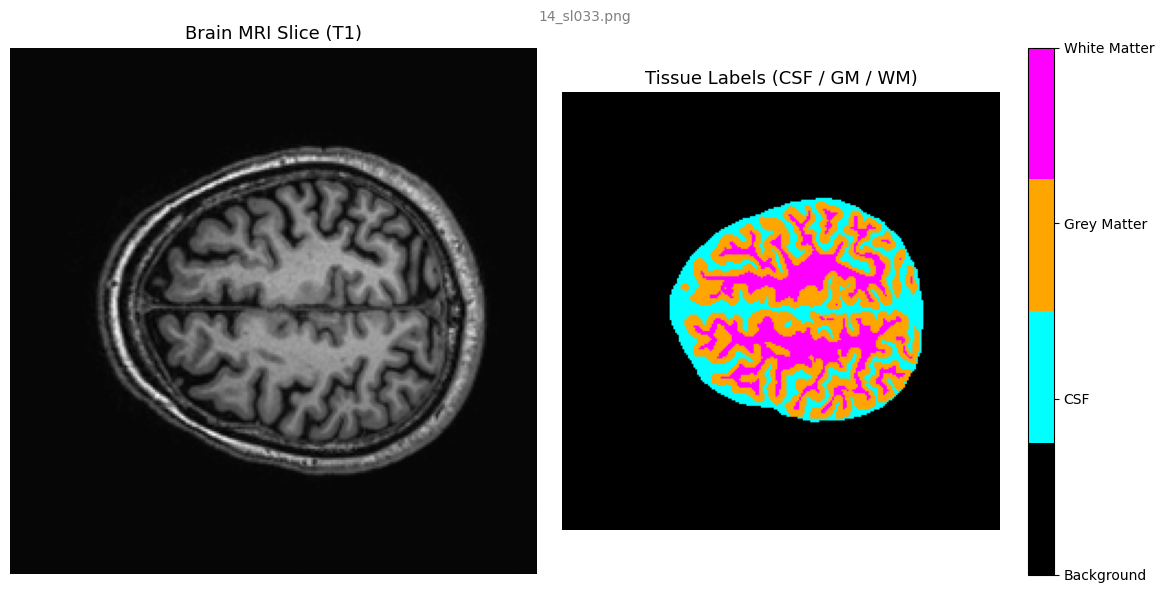

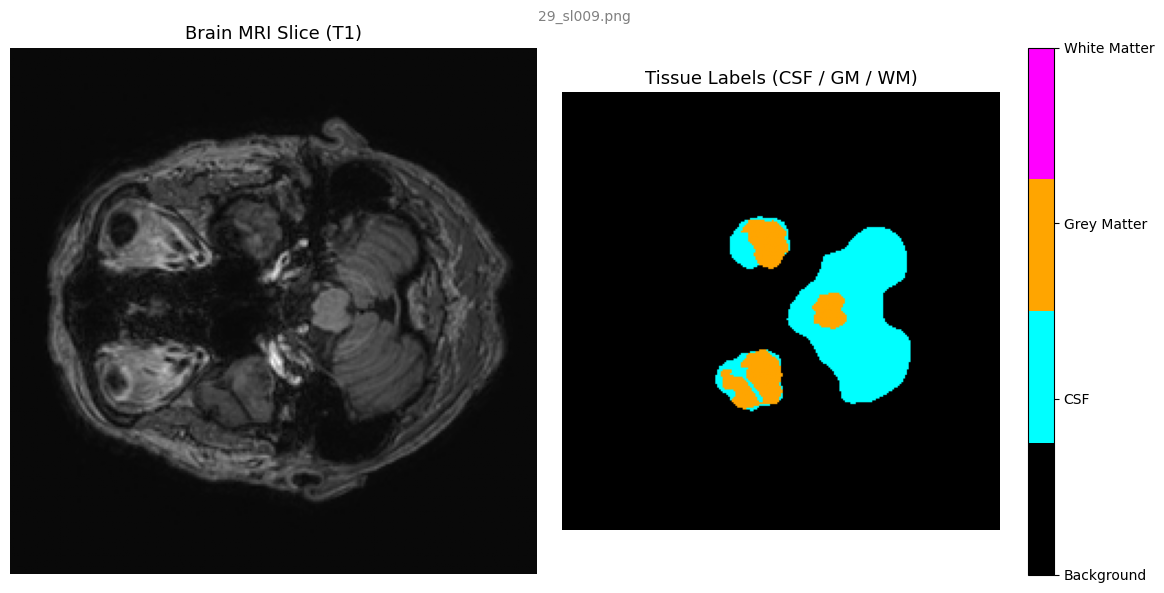

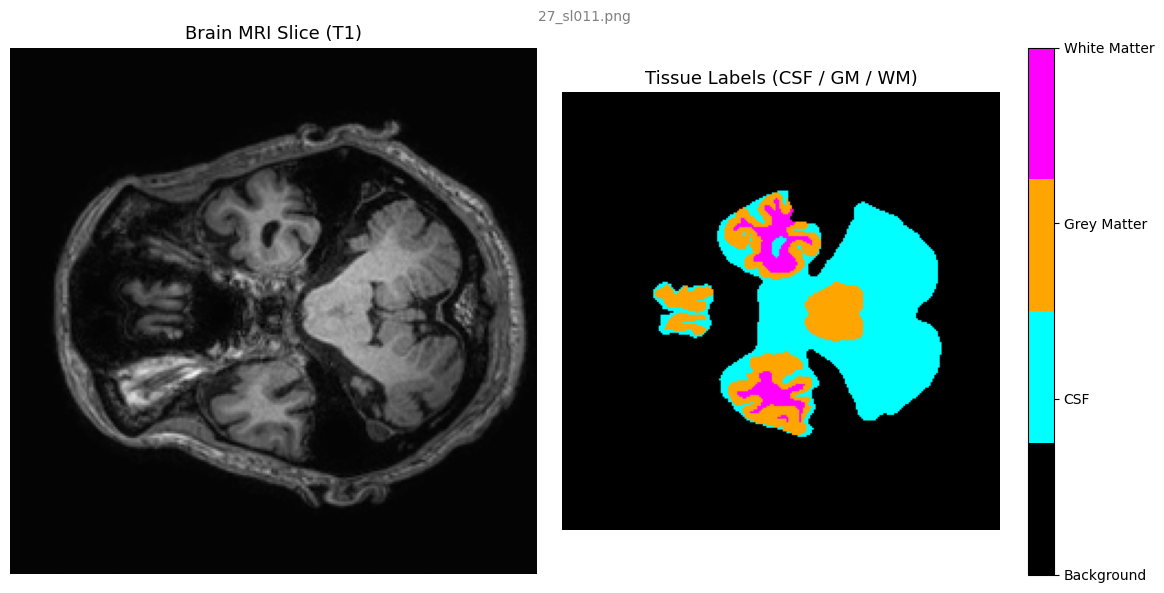

In [7]:
CLASS_COLORS = ['black', 'cyan', 'orange', 'magenta']
cmap_classes = mcolors.ListedColormap(CLASS_COLORS)

def visualize_sample(image_name):
    img  = cv2.imread(os.path.join(IMAGE_FOLDER, image_name), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(os.path.join(MASK_FOLDER,  image_name), cv2.IMREAD_GRAYSCALE)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Brain MRI Slice (T1)', fontsize=13)

    im = axes[1].imshow(mask, cmap=cmap_classes, vmin=0, vmax=NUM_CLASSES - 1)
    axes[1].set_title('Tissue Labels (CSF / GM / WM)', fontsize=13)
    cbar = plt.colorbar(im, ax=axes[1], ticks=range(NUM_CLASSES))
    cbar.ax.set_yticklabels(CLASS_NAMES)

    for ax in axes: ax.axis('off')
    plt.suptitle(image_name, fontsize=10, color='gray')
    plt.tight_layout()
    plt.show()


all_images = os.listdir(IMAGE_FOLDER)
for _ in range(4):
    visualize_sample(random.choice(all_images))

## 5. Train / Test Split

In [8]:
images = sorted([f for f in os.listdir(IMAGE_FOLDER) if f.endswith('.png')])
masks  = sorted([f for f in os.listdir(MASK_FOLDER)  if f.endswith('.png')])

assert images == masks, 'Image-mask mismatch!'

train_imgs, test_imgs = train_test_split(images, test_size=TEST_SPLIT, random_state=SEED)
print(f'Train: {len(train_imgs)}  |  Test: {len(test_imgs)}')

def copy_files(file_list, src_img, src_mask, dst_img, dst_mask):
    for f in tqdm(file_list, leave=False):
        shutil.copy(os.path.join(src_img,  f), os.path.join(dst_img,  f))
        shutil.copy(os.path.join(src_mask, f), os.path.join(dst_mask, f))

copy_files(train_imgs, IMAGE_FOLDER, MASK_FOLDER, TRAIN_IMG_DIR, TRAIN_MASK_DIR)
copy_files(test_imgs,  IMAGE_FOLDER, MASK_FOLDER, TEST_IMG_DIR,  TEST_MASK_DIR)
print('Files copied ✓')

Train: 268  |  Test: 68


Files copied ✓


## 6. tf.data Pipeline — with stronger augmentation (small dataset)

In [9]:
def load_image(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method='bilinear')
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE, method='nearest')
    mask = tf.cast(mask, tf.int32)
    mask = tf.squeeze(mask, axis=-1)
    mask = tf.one_hot(mask, depth=NUM_CLASSES)
    mask = tf.cast(mask, tf.float32)
    return img, mask


def augment(img, mask):
    # Stronger augmentation since dataset is small (7 subjects)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, mask


def build_dataset(img_dir, mask_dir, augment_data=False, batch=BATCH_SIZE):
    img_files  = sorted([os.path.join(img_dir,  f) for f in os.listdir(img_dir)  if f.endswith('.png')])
    mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith('.png')])
    ds = tf.data.Dataset.from_tensor_slices((img_files, mask_files))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds


train_dataset = build_dataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, augment_data=True)
test_dataset  = build_dataset(TEST_IMG_DIR,  TEST_MASK_DIR,  augment_data=False)

print('Datasets ready ✓')
for imgs, masks in train_dataset.take(1):
    print('Batch shapes → images:', imgs.shape, ' masks:', masks.shape)

I0000 00:00:1783414406.444282      57 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Datasets ready ✓
Batch shapes → images: (8, 224, 224, 3)  masks: (8, 224, 224, 4)


## 7. Model — FCN-8s (VGG16 backbone + transposed-conv upsampling), 4-class softmax output
**Simplest decoder** — fuses 3 coarse prediction stages via upsample-and-add instead of a full mirror decoder.

In [10]:
def build_model(input_shape=(224,224,3), num_classes=4, freeze_encoder=True):
    inputs=Input(shape=input_shape,name='input')
    base=VGG16(include_top=False,weights='imagenet',input_tensor=inputs)
    if freeze_encoder:
        for layer in base.layers: layer.trainable=False
    pool3=base.get_layer('block3_pool').output
    pool4=base.get_layer('block4_pool').output
    pool5=base.get_layer('block5_pool').output
    x=Conv2D(4096,(7,7),padding='same',activation='relu',name='fc6')(pool5)
    x=Dropout(0.5,name='fc6_drop')(x)
    x=Conv2D(4096,(1,1),padding='same',activation='relu',name='fc7')(x)
    x=Dropout(0.5,name='fc7_drop')(x)
    score5=Conv2D(num_classes,(1,1),padding='same',name='score_pool5')(x)
    up5=Conv2DTranspose(num_classes,(4,4),strides=2,padding='same',name='upscore_pool5')(score5)
    score4=Conv2D(num_classes,(1,1),padding='same',name='score_pool4')(pool4)
    fuse4=Add(name='fuse_pool4')([up5,score4])
    up4=Conv2DTranspose(num_classes,(4,4),strides=2,padding='same',name='upscore_pool4')(fuse4)
    score3=Conv2D(num_classes,(1,1),padding='same',name='score_pool3')(pool3)
    fuse3=Add(name='fuse_pool3')([up4,score3])
    up_final=Conv2DTranspose(num_classes,(16,16),strides=8,padding='same',name='upscore_final')(fuse3)
    output=Activation('softmax',name='output')(up_final)
    return Model(inputs=inputs,outputs=output,name='FCN8s_MultiClass_MRBrainS18')

model=build_model(input_shape=(*IMG_SIZE,3),num_classes=NUM_CLASSES)
print('Model built')
print(f'Total parameters     : {model.count_params():,}')
print(f'Trainable parameters : {sum([K.count_params(w) for w in model.trainable_weights]):,}')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Model built
Total parameters     : 134,284,632
Trainable parameters : 119,569,944


## 8. Custom Metrics & Loss

In [11]:
def dice_coefficient_multiclass(y_true, y_pred, smooth=1.0):
    y_true_f = K.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = K.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = K.sum(y_true_f * y_pred_f, axis=0)
    union = K.sum(y_true_f, axis=0) + K.sum(y_pred_f, axis=0)
    return K.mean((2.0 * intersection + smooth) / (union + smooth))

def dice_loss_multiclass(y_true, y_pred):
    return 1.0 - dice_coefficient_multiclass(y_true, y_pred)

def iou_score_multiclass(y_true, y_pred, smooth=1.0):
    y_true_f = K.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = K.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = K.sum(y_true_f * y_pred_f, axis=0)
    total = K.sum(y_true_f, axis=0) + K.sum(y_pred_f, axis=0) - intersection
    return K.mean((intersection + smooth) / (total + smooth))

def csf_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 1]; p = y_pred[..., 1]
    i = K.sum(t * p)
    return (i + smooth) / (K.sum(t) + K.sum(p) - i + smooth)

def gm_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 2]; p = y_pred[..., 2]
    i = K.sum(t * p)
    return (i + smooth) / (K.sum(t) + K.sum(p) - i + smooth)

def wm_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 3]; p = y_pred[..., 3]
    i = K.sum(t * p)
    return (i + smooth) / (K.sum(t) + K.sum(p) - i + smooth)

def pixel_accuracy_multiclass(y_true, y_pred):
    return K.mean(K.cast(K.equal(K.argmax(y_true, axis=-1), K.argmax(y_pred, axis=-1)), K.floatx()))

def combined_loss_multiclass(y_true, y_pred):
    return dice_loss_multiclass(y_true, y_pred) + tf.keras.losses.categorical_crossentropy(y_true, y_pred)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss_multiclass,
    metrics=[dice_coefficient_multiclass, iou_score_multiclass,
             pixel_accuracy_multiclass, csf_iou, gm_iou, wm_iou]
)
print('Model compiled ✓')

Model compiled ✓


## 9. Model Summary

In [12]:
model.summary()
try:
    tf.keras.utils.plot_model(model, to_file='fcn8s_mrbrains_architecture.png',
                               show_shapes=True, show_layer_names=True, dpi=64)
    print('Architecture diagram saved ✓')
except Exception as e:
    print('Architecture plot skipped:', str(e)[:100])

Model: "FCN8s_MultiClass_MRBrainS18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 134,284,632 (512.26 MB)

 Trainable params: 119,569,944 (456.12 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Architecture diagram saved ✓


## 10. Callbacks (EarlyStopping disabled)

In [13]:
def decode_mask(onehot_mask):
    return tf.argmax(onehot_mask, axis=-1)

def colorize_mask(label_map):
    colors = np.array([[0,0,0],[0,255,255],[255,165,0],[255,0,255]], dtype=np.uint8)
    return colors[np.array(label_map).astype(int)]

def show_predictions(dataset, num=3, model_to_use=None):
    m = model_to_use or model
    for imgs, masks in dataset.take(1):
        preds = m.predict(imgs, verbose=0)
        for i in range(min(num, len(imgs))):
            fig, axes = plt.subplots(1, 3, figsize=(13, 4))
            axes[0].imshow(imgs[i].numpy());                              axes[0].set_title('Input MRI')
            axes[1].imshow(colorize_mask(decode_mask(masks[i]).numpy())); axes[1].set_title('Ground Truth')
            axes[2].imshow(colorize_mask(decode_mask(preds[i]).numpy())); axes[2].set_title('Prediction')
            for ax in axes: ax.axis('off')
            plt.tight_layout(); plt.show()

class DisplayCallback(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            show_predictions(test_dataset, num=2)
            print(f'Prediction after epoch {epoch + 1}\n')

logdir = os.path.join('logs', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))

callbacks_list = [
    DisplayCallback(),
    callbacks.TensorBoard(logdir, histogram_freq=1),
    callbacks.ModelCheckpoint('best_model_fcn8s_mrbrains.keras', verbose=1,
                               save_best_only=True, monitor='val_iou_score_multiclass', mode='max'),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    # EarlyStopping intentionally removed
]
print('Callbacks ready ✓ (no EarlyStopping — will run all', EPOCHS, 'epochs)')

Callbacks ready ✓ (no EarlyStopping — will run all 100 epochs)


## 11. Initial Predictions (before training)

Predictions before training:


I0000 00:00:1783414418.892371     133 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


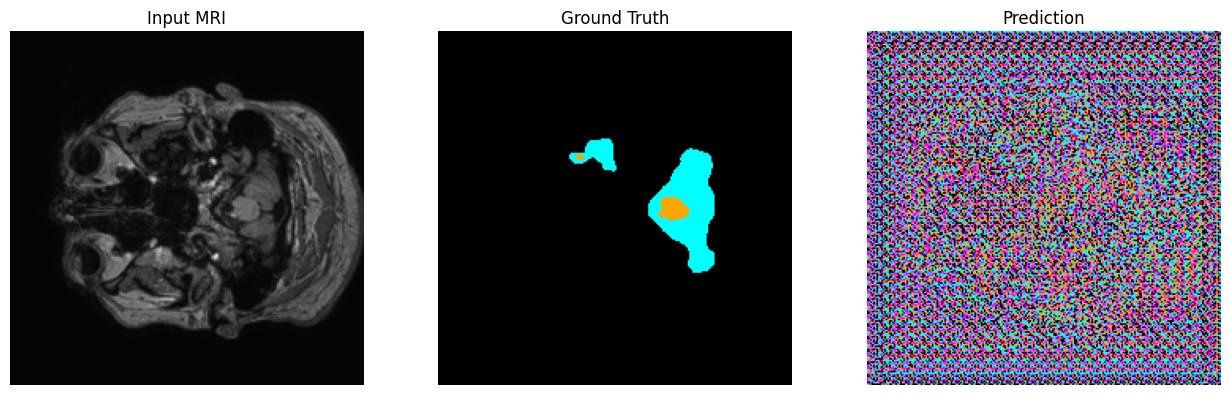

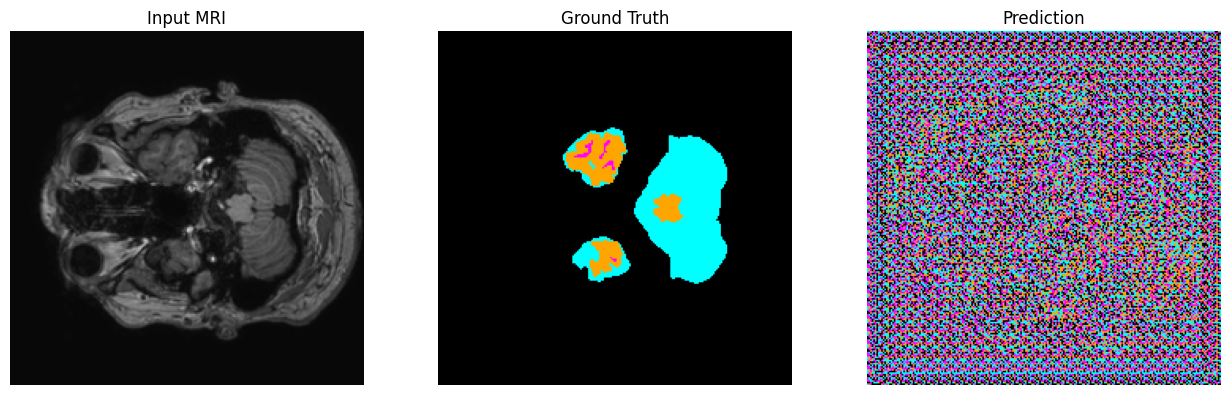

In [14]:
print('Predictions before training:')
show_predictions(test_dataset, num=2)

## 12. Training

Steps per epoch  : 33
Validation steps : 8
Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - csf_iou: 0.0595 - dice_coefficient_multiclass: 0.1799 - gm_iou: 0.0599 - iou_score_multiclass: 0.1071 - loss: 2.5418 - pixel_accuracy_multiclass: 0.3059 - wm_iou: 0.0376
Epoch 1: val_iou_score_multiclass improved from None to 0.12784, saving model to best_model_fcn8s_mrbrains.keras

Epoch 1: finished saving model to best_model_fcn8s_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 43s 998ms/step - csf_iou: 0.0589 - dice_coefficient_multiclass: 0.1869 - gm_iou: 0.0599 - iou_score_multiclass: 0.1127 - loss: 2.4384 - pixel_accuracy_multiclass: 0.3423 - wm_iou: 0.0397 - val_csf_iou: 0.0625 - val_dice_coefficient_multiclass: 0.2077 - val_gm_iou: 0.0641 - val_iou_score_multiclass: 0.1278 - val_loss: 2.2378 - val_pixel_accuracy_multiclass: 0.4159 - val_wm_iou: 0.0448 - learning_rate: 1.0000e-04
Epoch 2/100
 1/33 ━━━━━━━━━━━━━━━━━━━━ 3:43 7s/step - csf_iou: 0.0065 - dice_coefficient_multiclass: 0.1356 - g

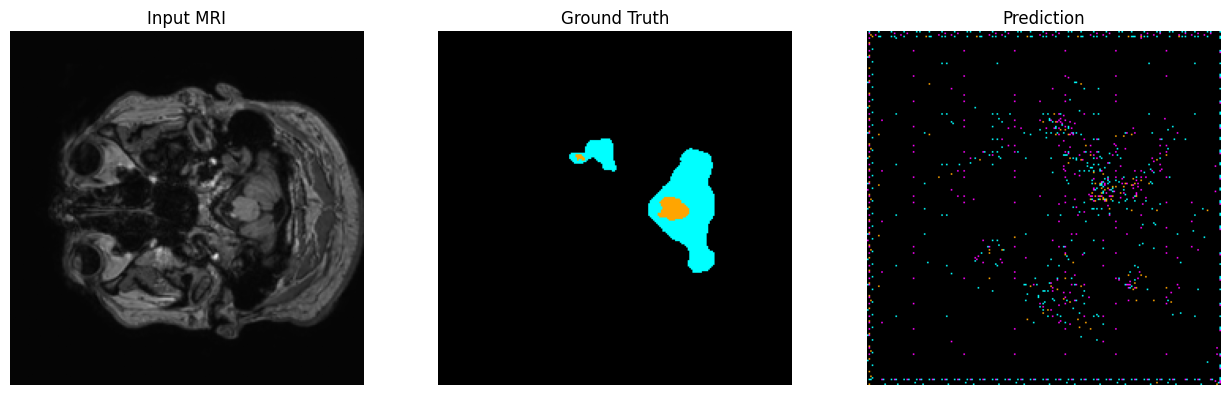

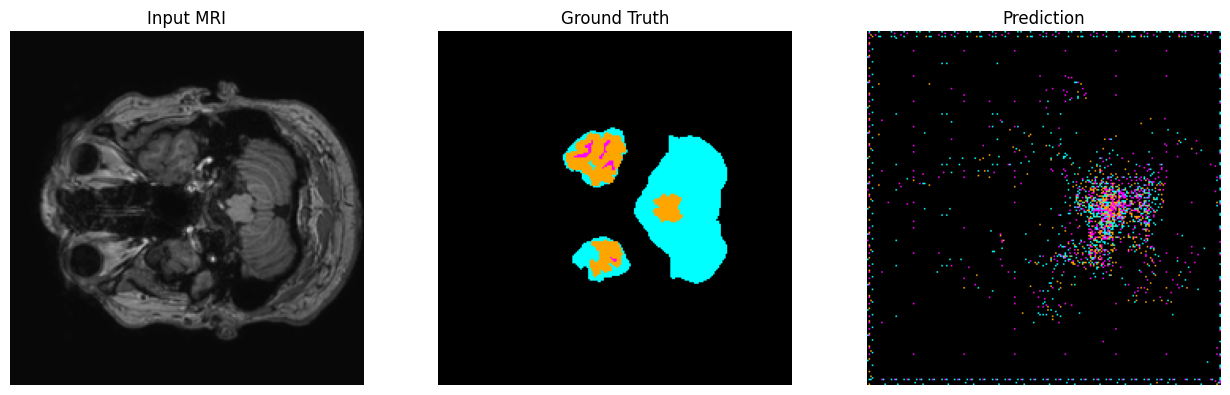

Prediction after epoch 10


Epoch 10: val_iou_score_multiclass improved from 0.33477 to 0.33547, saving model to best_model_fcn8s_mrbrains.keras

Epoch 10: finished saving model to best_model_fcn8s_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 29s 912ms/step - csf_iou: 0.0213 - dice_coefficient_multiclass: 0.2554 - gm_iou: 0.0011 - iou_score_multiclass: 0.2451 - loss: 0.8178 - pixel_accuracy_multiclass: 0.9798 - wm_iou: 3.5837e-04 - val_csf_iou: 0.1312 - val_dice_coefficient_multiclass: 0.4314 - val_gm_iou: 0.1768 - val_iou_score_multiclass: 0.3355 - val_loss: 1.0226 - val_pixel_accuracy_multiclass: 0.8362 - val_wm_iou: 0.1446 - learning_rate: 1.0000e-04
Epoch 11/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - csf_iou: 0.1288 - dice_coefficient_multiclass: 0.4052 - gm_iou: 0.1601 - iou_score_multiclass: 0.3201 - loss: 1.0471 - pixel_accuracy_multiclass: 0.8346 - wm_iou: 0.1045
Epoch 11: val_iou_score_multiclass improved from 0.33547 to 0.34749, saving model to best_model_fcn8s_mrbrains.keras

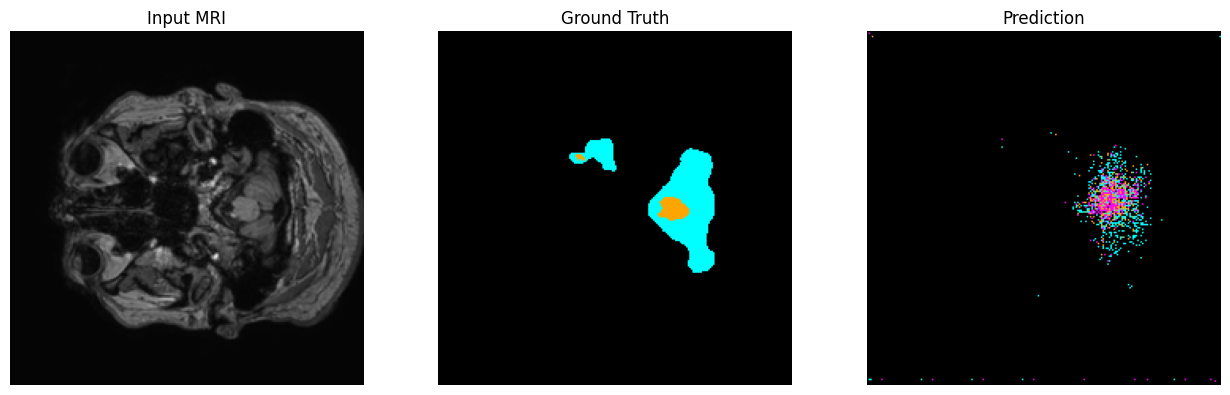

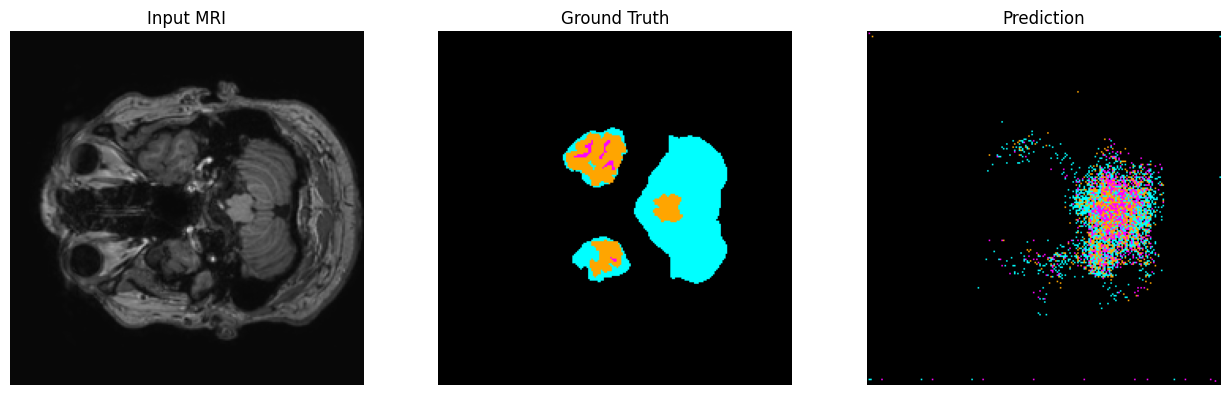

Prediction after epoch 20


Epoch 20: val_iou_score_multiclass improved from 0.38263 to 0.38284, saving model to best_model_fcn8s_mrbrains.keras

Epoch 20: finished saving model to best_model_fcn8s_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 29s 899ms/step - csf_iou: 0.1438 - dice_coefficient_multiclass: 0.3152 - gm_iou: 0.0077 - iou_score_multiclass: 0.2857 - loss: 0.7066 - pixel_accuracy_multiclass: 0.9928 - wm_iou: 0.0021 - val_csf_iou: 0.1860 - val_dice_coefficient_multiclass: 0.4885 - val_gm_iou: 0.2148 - val_iou_score_multiclass: 0.3828 - val_loss: 0.8411 - val_pixel_accuracy_multiclass: 0.8613 - val_wm_iou: 0.1888 - learning_rate: 1.0000e-04
Epoch 21/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - csf_iou: 0.1898 - dice_coefficient_multiclass: 0.4626 - gm_iou: 0.2013 - iou_score_multiclass: 0.3671 - loss: 0.8645 - pixel_accuracy_multiclass: 0.8625 - wm_iou: 0.1361
Epoch 21: val_iou_score_multiclass improved from 0.38284 to 0.38701, saving model to best_model_fcn8s_mrbrains.keras

Ep

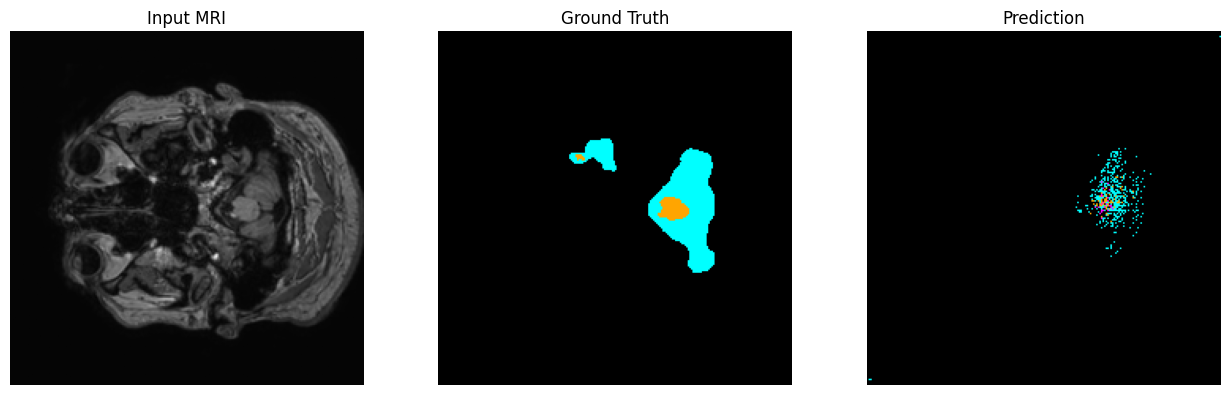

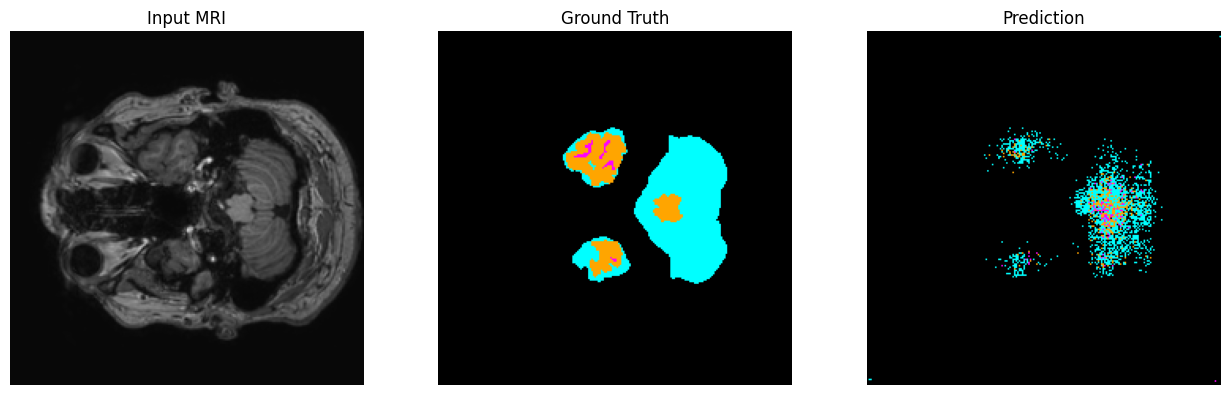

Prediction after epoch 30


Epoch 30: val_iou_score_multiclass improved from 0.41943 to 0.42001, saving model to best_model_fcn8s_mrbrains.keras

Epoch 30: finished saving model to best_model_fcn8s_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 29s 911ms/step - csf_iou: 0.2236 - dice_coefficient_multiclass: 0.3493 - gm_iou: 0.0149 - iou_score_multiclass: 0.3110 - loss: 0.6660 - pixel_accuracy_multiclass: 0.9944 - wm_iou: 0.0121 - val_csf_iou: 0.2471 - val_dice_coefficient_multiclass: 0.5361 - val_gm_iou: 0.2238 - val_iou_score_multiclass: 0.4200 - val_loss: 0.7401 - val_pixel_accuracy_multiclass: 0.8799 - val_wm_iou: 0.2563 - learning_rate: 1.0000e-04
Epoch 31/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - csf_iou: 0.2540 - dice_coefficient_multiclass: 0.5030 - gm_iou: 0.2101 - iou_score_multiclass: 0.3978 - loss: 0.7789 - pixel_accuracy_multiclass: 0.8772 - wm_iou: 0.1776
Epoch 31: val_iou_score_multiclass improved from 0.42001 to 0.42567, saving model to best_model_fcn8s_mrbrains.keras

Ep

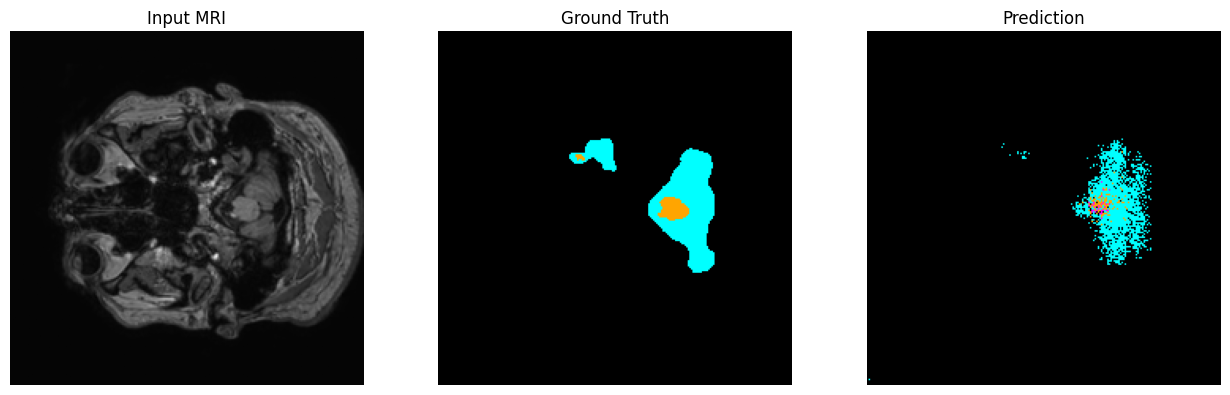

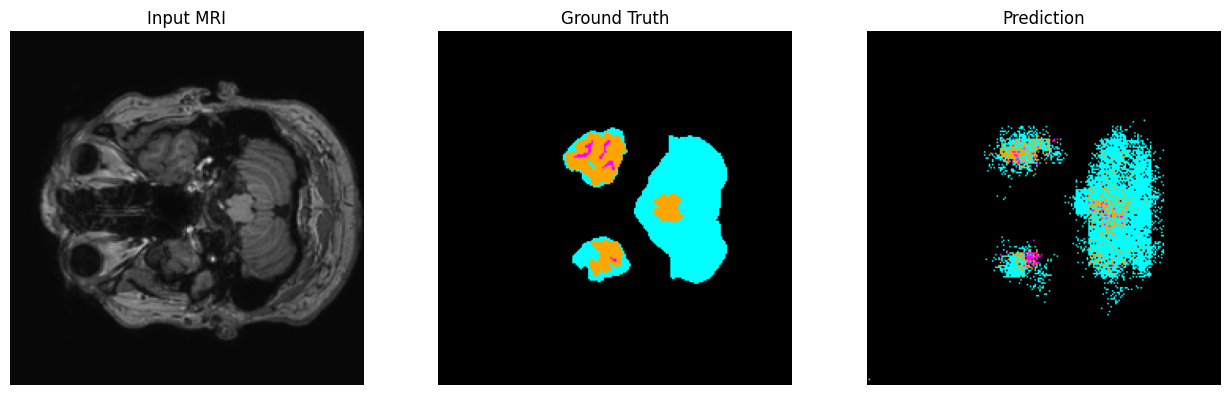

Prediction after epoch 40


Epoch 40: val_iou_score_multiclass did not improve from 0.45969
33/33 ━━━━━━━━━━━━━━━━━━━━ 22s 694ms/step - csf_iou: 0.3122 - dice_coefficient_multiclass: 0.3897 - gm_iou: 0.0196 - iou_score_multiclass: 0.3466 - loss: 0.6225 - pixel_accuracy_multiclass: 0.9947 - wm_iou: 0.0607 - val_csf_iou: 0.3107 - val_dice_coefficient_multiclass: 0.5838 - val_gm_iou: 0.2454 - val_iou_score_multiclass: 0.4596 - val_loss: 0.6632 - val_pixel_accuracy_multiclass: 0.8924 - val_wm_iou: 0.3251 - learning_rate: 1.0000e-04
Epoch 41/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - csf_iou: 0.3210 - dice_coefficient_multiclass: 0.5507 - gm_iou: 0.2330 - iou_score_multiclass: 0.4363 - loss: 0.6939 - pixel_accuracy_multiclass: 0.8926 - wm_iou: 0.2326
Epoch 41: val_iou_score_multiclass improved from 0.45969 to 0.46530, saving model to best_model_fcn8s_mrbrains.keras

Epoch 41: finished saving model to best_model_fcn8s_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 30s 942ms/step - csf_iou: 0.3

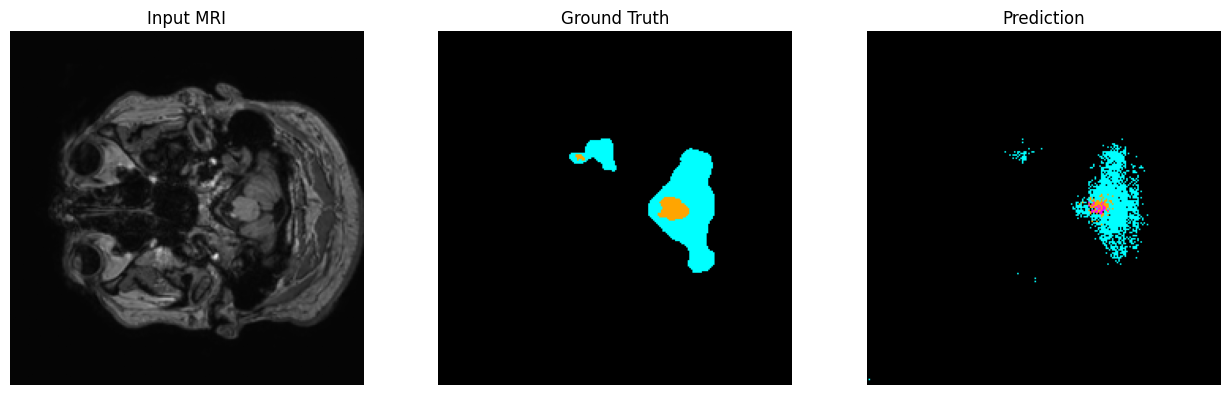

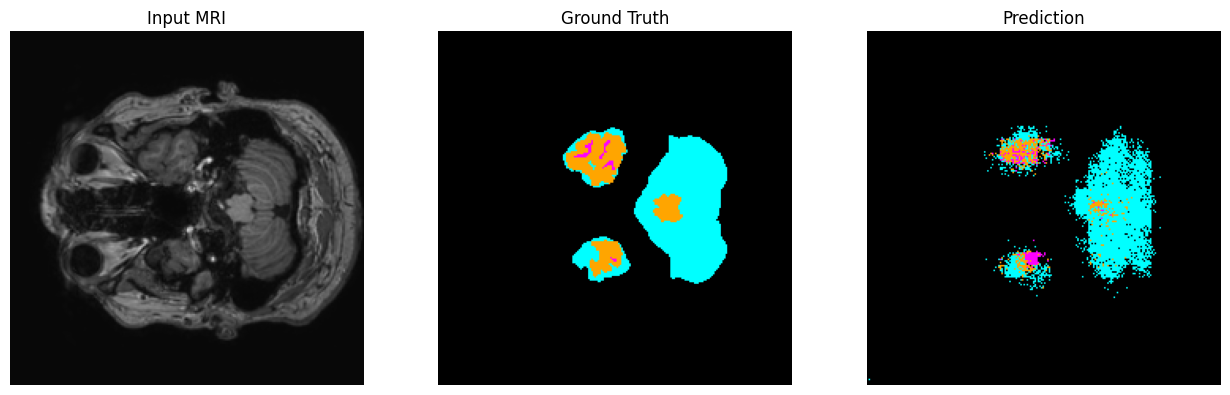

Prediction after epoch 50


Epoch 50: val_iou_score_multiclass improved from 0.48709 to 0.48736, saving model to best_model_fcn8s_mrbrains.keras

Epoch 50: finished saving model to best_model_fcn8s_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 29s 895ms/step - csf_iou: 0.4830 - dice_coefficient_multiclass: 0.4607 - gm_iou: 0.0193 - iou_score_multiclass: 0.4170 - loss: 0.5486 - pixel_accuracy_multiclass: 0.9963 - wm_iou: 0.1705 - val_csf_iou: 0.3566 - val_dice_coefficient_multiclass: 0.6144 - val_gm_iou: 0.2650 - val_iou_score_multiclass: 0.4874 - val_loss: 0.6055 - val_pixel_accuracy_multiclass: 0.9048 - val_wm_iou: 0.3633 - learning_rate: 1.0000e-04
Epoch 51/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - csf_iou: 0.3598 - dice_coefficient_multiclass: 0.5779 - gm_iou: 0.2550 - iou_score_multiclass: 0.4601 - loss: 0.6470 - pixel_accuracy_multiclass: 0.9023 - wm_iou: 0.2626
Epoch 51: val_iou_score_multiclass improved from 0.48736 to 0.49232, saving model to best_model_fcn8s_mrbrains.keras

Ep

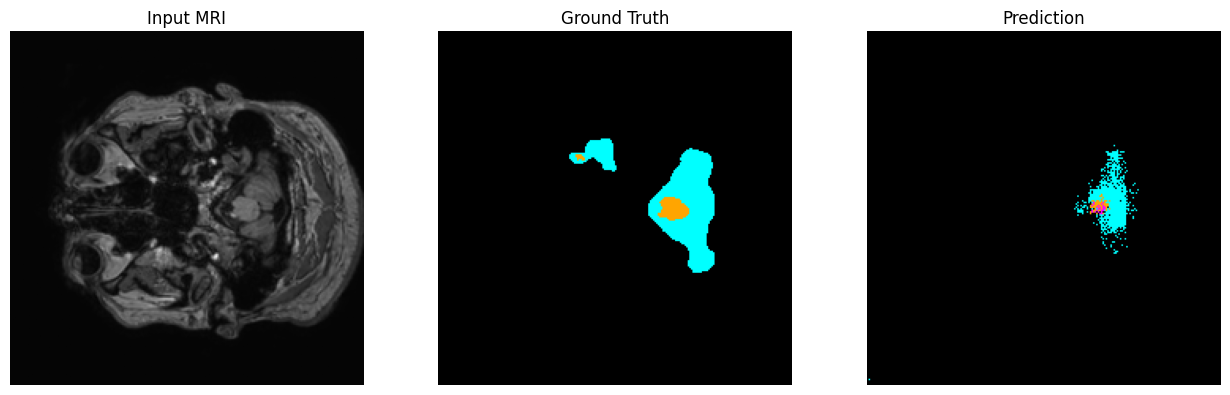

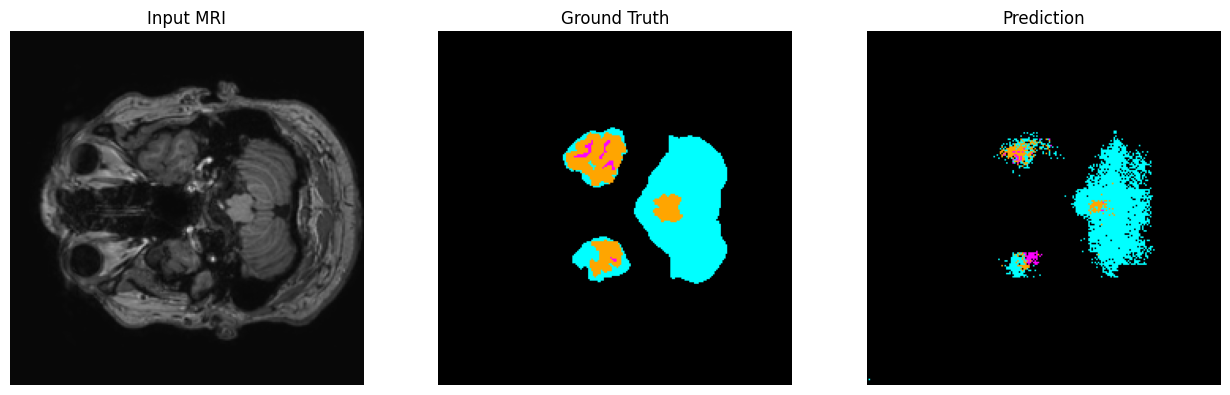

Prediction after epoch 60


Epoch 60: val_iou_score_multiclass did not improve from 0.50036
33/33 ━━━━━━━━━━━━━━━━━━━━ 21s 670ms/step - csf_iou: 0.4907 - dice_coefficient_multiclass: 0.5756 - gm_iou: 0.0497 - iou_score_multiclass: 0.5326 - loss: 0.4329 - pixel_accuracy_multiclass: 0.9965 - wm_iou: 0.5942 - val_csf_iou: 0.3696 - val_dice_coefficient_multiclass: 0.6221 - val_gm_iou: 0.2714 - val_iou_score_multiclass: 0.4943 - val_loss: 0.6013 - val_pixel_accuracy_multiclass: 0.9078 - val_wm_iou: 0.3721 - learning_rate: 1.0000e-04
Epoch 61/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - csf_iou: 0.3781 - dice_coefficient_multiclass: 0.5936 - gm_iou: 0.2672 - iou_score_multiclass: 0.4733 - loss: 0.6279 - pixel_accuracy_multiclass: 0.9061 - wm_iou: 0.2846
Epoch 61: val_iou_score_multiclass improved from 0.50036 to 0.50205, saving model to best_model_fcn8s_mrbrains.keras

Epoch 61: finished saving model to best_model_fcn8s_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 30s 942ms/step - csf_iou: 0.3

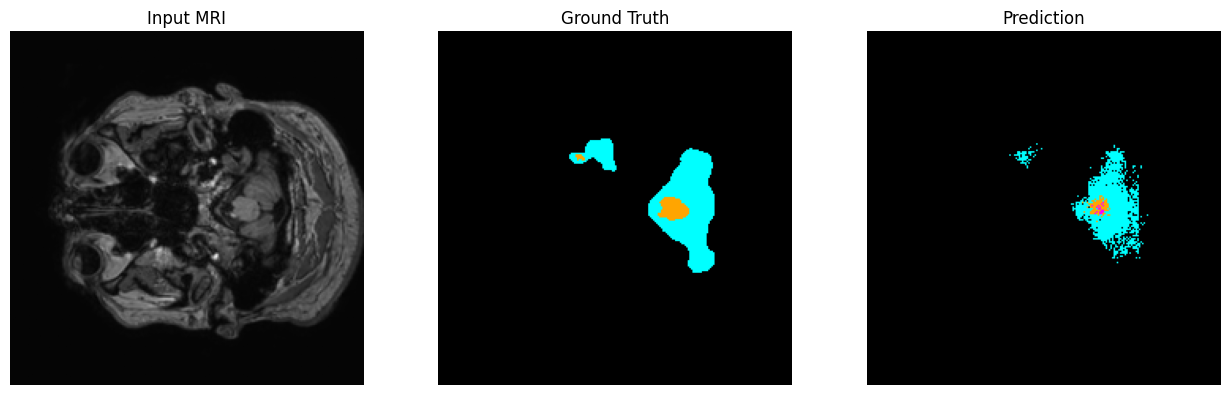

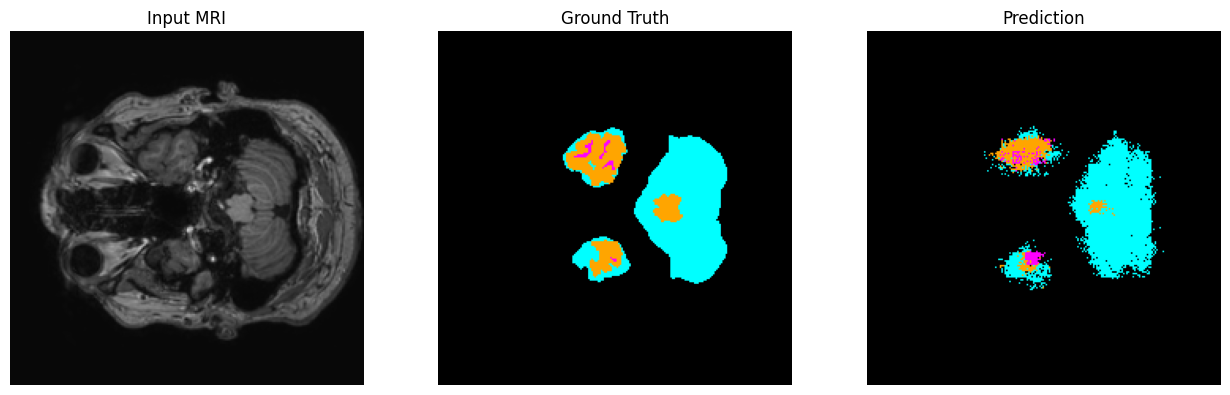

Prediction after epoch 70


Epoch 70: val_iou_score_multiclass did not improve from 0.52561
33/33 ━━━━━━━━━━━━━━━━━━━━ 23s 709ms/step - csf_iou: 0.5444 - dice_coefficient_multiclass: 0.6645 - gm_iou: 0.0496 - iou_score_multiclass: 0.6234 - loss: 0.3454 - pixel_accuracy_multiclass: 0.9960 - wm_iou: 0.9042 - val_csf_iou: 0.4069 - val_dice_coefficient_multiclass: 0.6544 - val_gm_iou: 0.3112 - val_iou_score_multiclass: 0.5249 - val_loss: 0.5429 - val_pixel_accuracy_multiclass: 0.9162 - val_wm_iou: 0.4114 - learning_rate: 1.0000e-04
Epoch 71/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - csf_iou: 0.4188 - dice_coefficient_multiclass: 0.6233 - gm_iou: 0.3034 - iou_score_multiclass: 0.5008 - loss: 0.5704 - pixel_accuracy_multiclass: 0.9166 - wm_iou: 0.3106
Epoch 71: val_iou_score_multiclass improved from 0.52561 to 0.52779, saving model to best_model_fcn8s_mrbrains.keras

Epoch 71: finished saving model to best_model_fcn8s_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 30s 938ms/step - csf_iou: 0.4

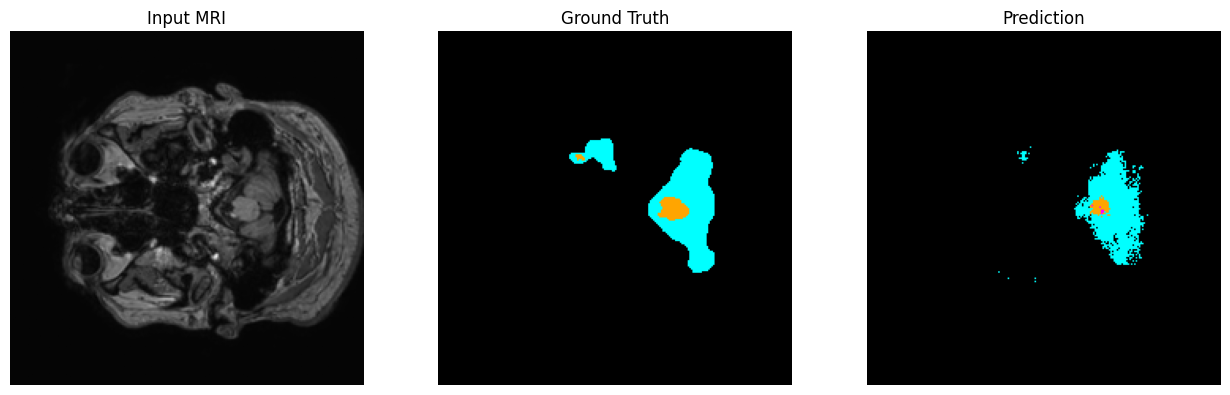

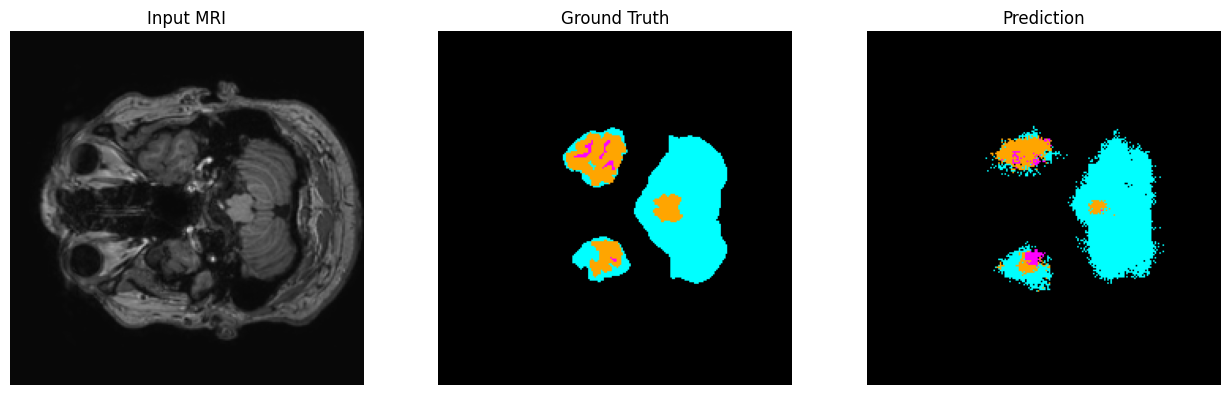

Prediction after epoch 80


Epoch 80: val_iou_score_multiclass did not improve from 0.53937
33/33 ━━━━━━━━━━━━━━━━━━━━ 22s 693ms/step - csf_iou: 0.6197 - dice_coefficient_multiclass: 0.6977 - gm_iou: 0.0567 - iou_score_multiclass: 0.6608 - loss: 0.3107 - pixel_accuracy_multiclass: 0.9969 - wm_iou: 0.9704 - val_csf_iou: 0.4257 - val_dice_coefficient_multiclass: 0.6685 - val_gm_iou: 0.3293 - val_iou_score_multiclass: 0.5386 - val_loss: 0.5224 - val_pixel_accuracy_multiclass: 0.9199 - val_wm_iou: 0.4279 - learning_rate: 1.0000e-04
Epoch 81/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - csf_iou: 0.4377 - dice_coefficient_multiclass: 0.6382 - gm_iou: 0.3234 - iou_score_multiclass: 0.5146 - loss: 0.5470 - pixel_accuracy_multiclass: 0.9209 - wm_iou: 0.3249
Epoch 81: val_iou_score_multiclass improved from 0.53937 to 0.54036, saving model to best_model_fcn8s_mrbrains.keras

Epoch 81: finished saving model to best_model_fcn8s_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 30s 939ms/step - csf_iou: 0.4

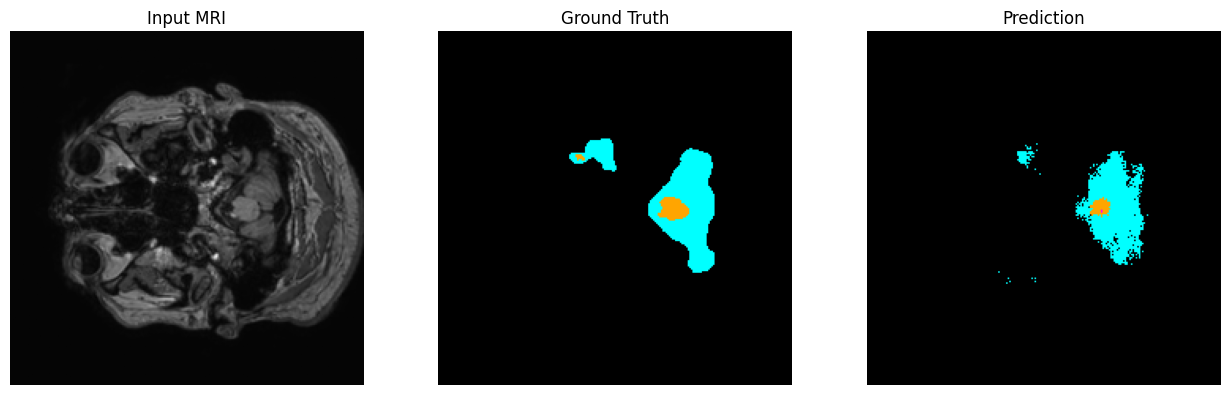

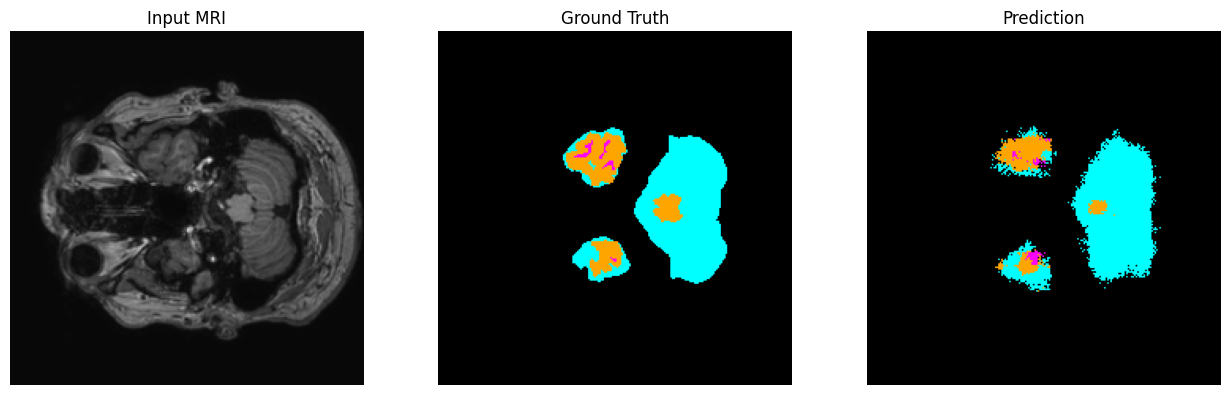

Prediction after epoch 90


Epoch 90: val_iou_score_multiclass did not improve from 0.55038
33/33 ━━━━━━━━━━━━━━━━━━━━ 22s 685ms/step - csf_iou: 0.6321 - dice_coefficient_multiclass: 0.7071 - gm_iou: 0.0667 - iou_score_multiclass: 0.6711 - loss: 0.2989 - pixel_accuracy_multiclass: 0.9977 - wm_iou: 0.9886 - val_csf_iou: 0.4394 - val_dice_coefficient_multiclass: 0.6798 - val_gm_iou: 0.3438 - val_iou_score_multiclass: 0.5498 - val_loss: 0.5065 - val_pixel_accuracy_multiclass: 0.9226 - val_wm_iou: 0.4431 - learning_rate: 1.0000e-04
Epoch 91/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - csf_iou: 0.4592 - dice_coefficient_multiclass: 0.6529 - gm_iou: 0.3455 - iou_score_multiclass: 0.5289 - loss: 0.5242 - pixel_accuracy_multiclass: 0.9247 - wm_iou: 0.3359
Epoch 91: val_iou_score_multiclass improved from 0.55038 to 0.55217, saving model to best_model_fcn8s_mrbrains.keras

Epoch 91: finished saving model to best_model_fcn8s_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 30s 940ms/step - csf_iou: 0.4

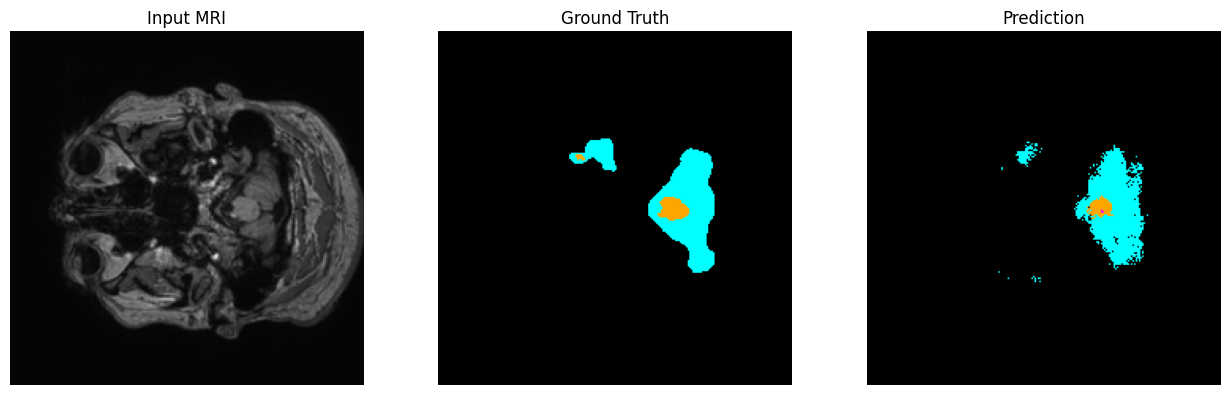

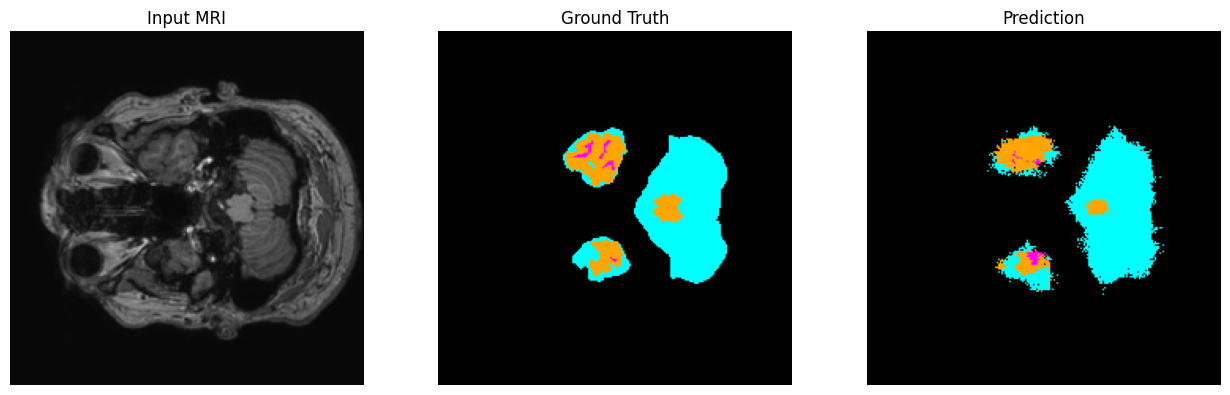

Prediction after epoch 100


Epoch 100: val_iou_score_multiclass did not improve from 0.55994
33/33 ━━━━━━━━━━━━━━━━━━━━ 22s 686ms/step - csf_iou: 0.6899 - dice_coefficient_multiclass: 0.7187 - gm_iou: 0.0651 - iou_score_multiclass: 0.6867 - loss: 0.2868 - pixel_accuracy_multiclass: 0.9979 - wm_iou: 0.9942 - val_csf_iou: 0.4488 - val_dice_coefficient_multiclass: 0.6892 - val_gm_iou: 0.3587 - val_iou_score_multiclass: 0.5592 - val_loss: 0.4964 - val_pixel_accuracy_multiclass: 0.9239 - val_wm_iou: 0.4564 - learning_rate: 1.0000e-04

Training time: 49.5 min


In [15]:
steps_per_epoch  = max(1, len(os.listdir(TRAIN_IMG_DIR)) // BATCH_SIZE)
validation_steps = max(1, len(os.listdir(TEST_IMG_DIR))  // BATCH_SIZE)

print(f'Steps per epoch  : {steps_per_epoch}')
print(f'Validation steps : {validation_steps}')

start_time = time.time()
history = model.fit(
    train_dataset, validation_data=test_dataset, epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch, validation_steps=validation_steps,
    callbacks=callbacks_list
)
print(f'\nTraining time: {(time.time()-start_time)/60:.1f} min')

## 13. Training Graphs

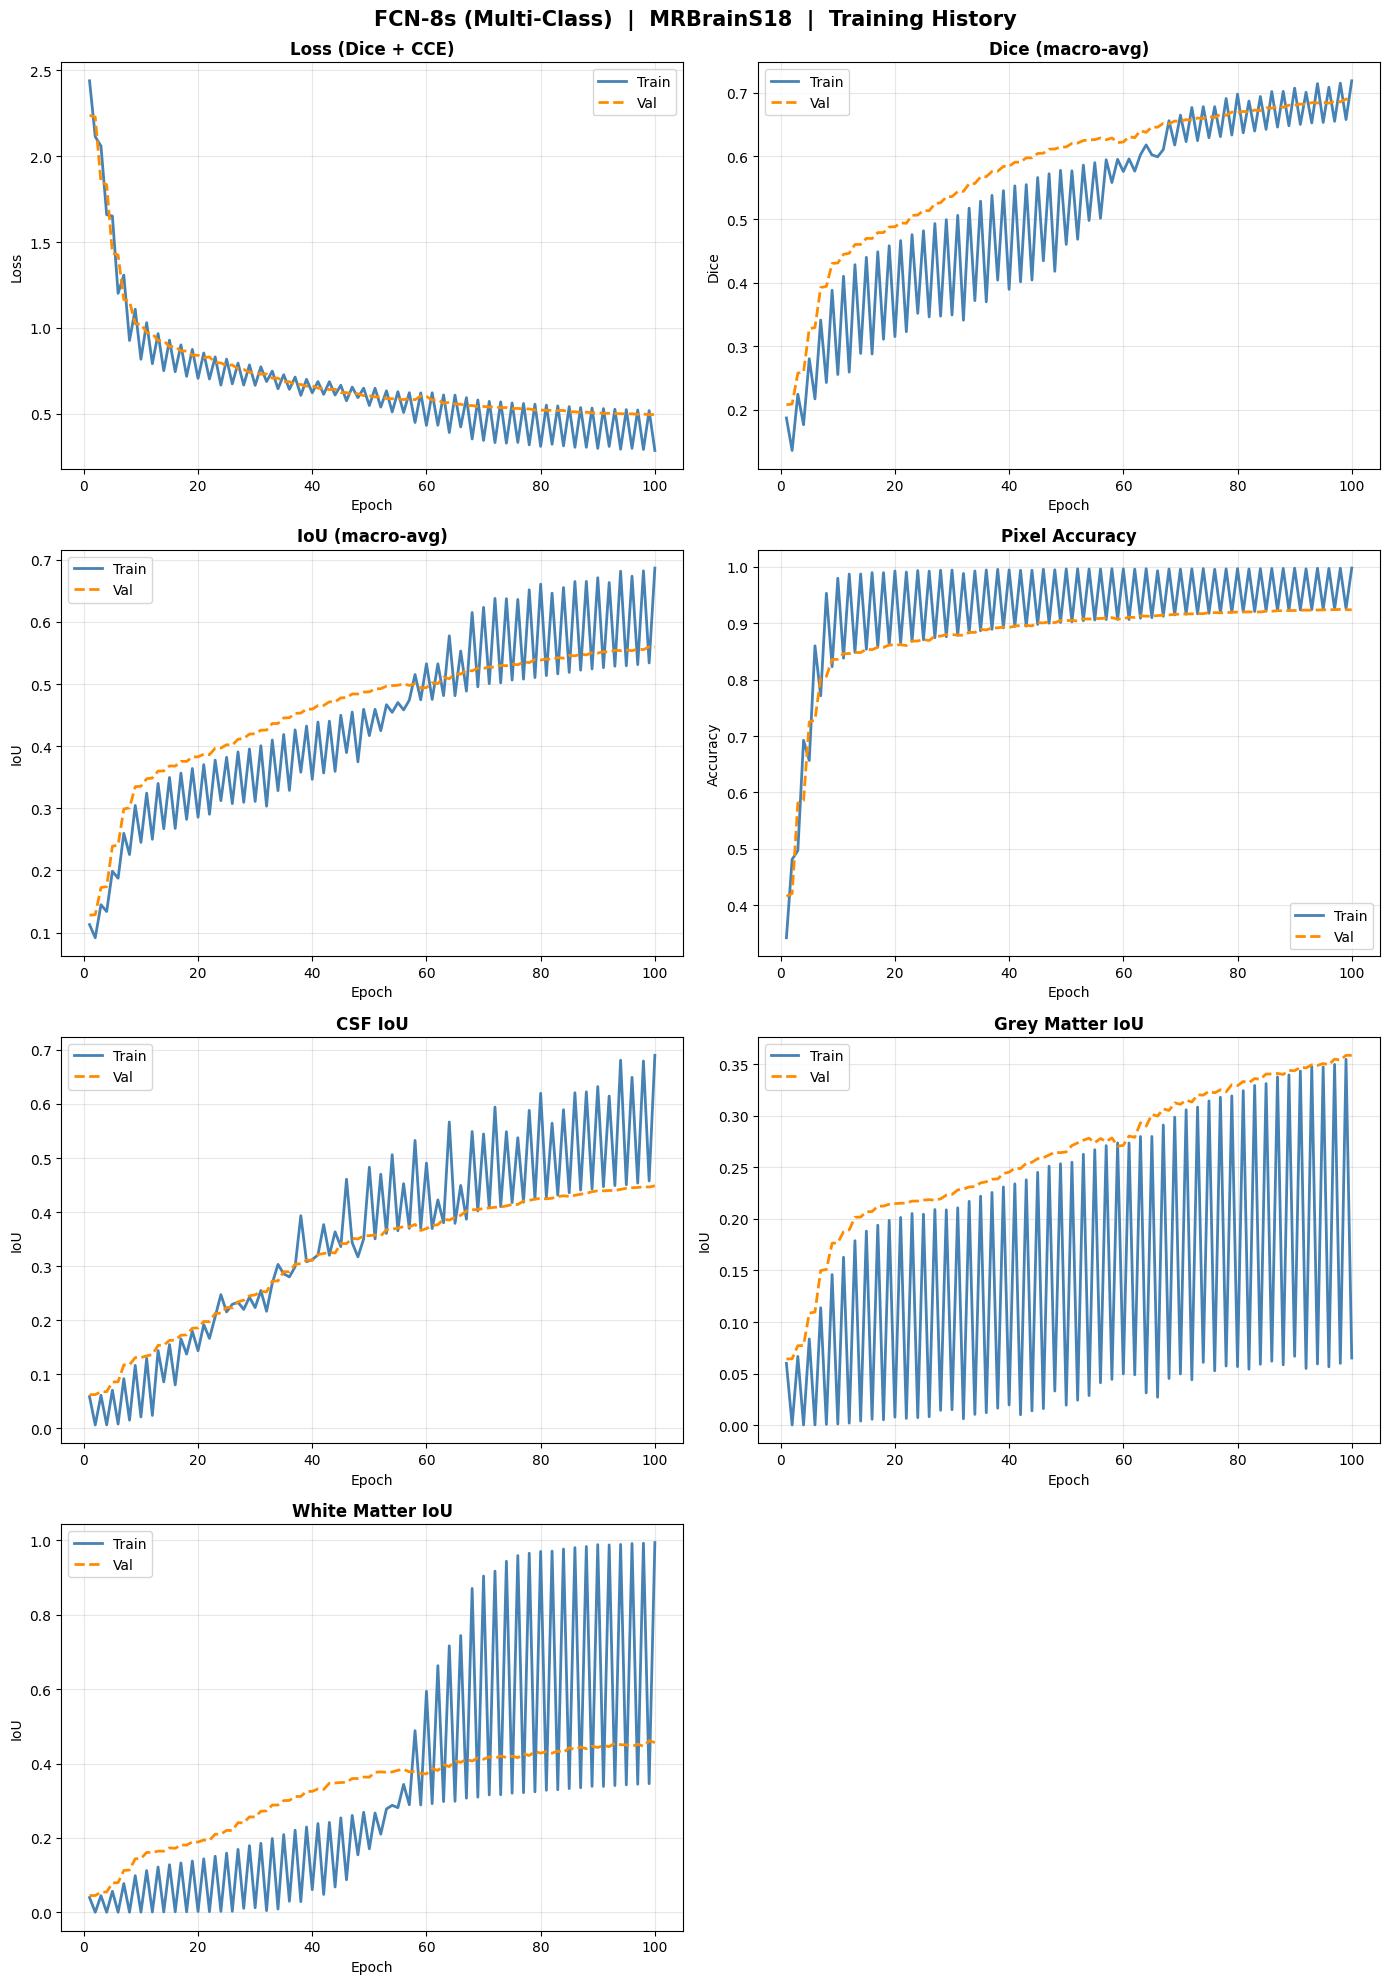

Plot saved ✓


In [16]:
H = history.history

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
fig.suptitle('FCN-8s (Multi-Class)  |  MRBrainS18  |  Training History',
             fontsize=15, fontweight='bold', y=0.99)

plot_specs = [
    ('loss', 'val_loss', 'Loss (Dice + CCE)', 'Loss'),
    ('dice_coefficient_multiclass', 'val_dice_coefficient_multiclass', 'Dice (macro-avg)', 'Dice'),
    ('iou_score_multiclass', 'val_iou_score_multiclass', 'IoU (macro-avg)', 'IoU'),
    ('pixel_accuracy_multiclass', 'val_pixel_accuracy_multiclass', 'Pixel Accuracy', 'Accuracy'),
    ('csf_iou', 'val_csf_iou', 'CSF IoU', 'IoU'),
    ('gm_iou', 'val_gm_iou', 'Grey Matter IoU', 'IoU'),
    ('wm_iou', 'val_wm_iou', 'White Matter IoU', 'IoU'),
]

for ax, (tk, vk, title, ylabel) in zip(axes.flatten(), plot_specs):
    er = range(1, len(H[tk]) + 1)
    ax.plot(er, H[tk], label='Train', color='steelblue', linewidth=2)
    ax.plot(er, H[vk], label='Val', color='darkorange', linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

axes.flatten()[-1].axis('off')
plt.tight_layout()
plt.savefig('training_history_fcn8s_mrbrains.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved ✓')

## 14. Best & Average Metrics Table

In [17]:
metric_spec = [
    ('Loss', 'loss', 'min'),
    ('Dice (macro-avg)', 'dice_coefficient_multiclass', 'max'),
    ('IoU (macro-avg)', 'iou_score_multiclass', 'max'),
    ('Pixel Accuracy', 'pixel_accuracy_multiclass', 'max'),
    ('CSF IoU', 'csf_iou', 'max'),
    ('Grey Matter IoU', 'gm_iou', 'max'),
    ('White Matter IoU', 'wm_iou', 'max'),
]

rows = []
for disp, key, mode in metric_spec:
    tr = np.asarray(H[key], dtype=np.float64)
    va = np.asarray(H['val_' + key], dtype=np.float64)
    pick = np.min if mode == 'min' else np.max
    rows.append({'Metric': disp, 'Train Best': pick(tr), 'Train Avg': tr.mean(),
                 'Val Best': pick(va), 'Val Avg': va.mean()})

report = pd.DataFrame(rows).set_index('Metric').round(4)

print('=' * 68)
print('   BEST & AVERAGE METRICS  —  FCN-8s Multi-Class  |  MRBrainS18')
print('=' * 68)
print(report.to_string())
print('=' * 68)
best_epoch = int(np.argmax(H['val_iou_score_multiclass'])) + 1
print(f'\nBest Val IoU (macro-avg): {max(H["val_iou_score_multiclass"]):.4f}  (epoch {best_epoch})')
print(f'Best Val CSF IoU         : {max(H["val_csf_iou"]):.4f}')
print(f'Best Val Grey Matter IoU : {max(H["val_gm_iou"]):.4f}')
print(f'Best Val White Matter IoU: {max(H["val_wm_iou"]):.4f}')
report

   BEST & AVERAGE METRICS  —  FCN-8s Multi-Class  |  MRBrainS18
                  Train Best  Train Avg  Val Best  Val Avg
Metric                                                    
Loss                  0.2868     0.6770    0.4955   0.7233
Dice (macro-avg)      0.7187     0.5146    0.6898   0.5768
IoU (macro-avg)       0.6867     0.4407    0.5599   0.4571
Pixel Accuracy        0.9979     0.9226    0.9245   0.8770
CSF IoU               0.6899     0.3494    0.4488   0.3156
Grey Matter IoU       0.3548     0.1397    0.3587   0.2619
White Matter IoU      0.9942     0.3306    0.4613   0.3223

Best Val IoU (macro-avg): 0.5599  (epoch 99)
Best Val CSF IoU         : 0.4488
Best Val Grey Matter IoU : 0.3587
Best Val White Matter IoU: 0.4613


,Train Best,Train Avg,Val Best,Val Avg
Metric,,,,
Loss,0.2868,0.6770,0.4955,0.7233
Dice (macro-avg),0.7187,0.5146,0.6898,0.5768
IoU (macro-avg),0.6867,0.4407,0.5599,0.4571
Pixel Accuracy,0.9979,0.9226,0.9245,0.8770
CSF IoU,0.6899,0.3494,0.4488,0.3156
Grey Matter IoU,0.3548,0.1397,0.3587,0.2619
White Matter IoU,0.9942,0.3306,0.4613,0.3223


## 15. Load Best Model & Final Evaluation

In [18]:
best_model = tf.keras.models.load_model(
    'best_model_fcn8s_mrbrains.keras',
    custom_objects={
        'combined_loss_multiclass': combined_loss_multiclass,
        'dice_coefficient_multiclass': dice_coefficient_multiclass,
        'iou_score_multiclass': iou_score_multiclass,
        'pixel_accuracy_multiclass': pixel_accuracy_multiclass,
        'csf_iou': csf_iou, 'gm_iou': gm_iou, 'wm_iou': wm_iou,
    }
)
print('Best model loaded ✓')

Best model loaded ✓


In [19]:
test_results = best_model.evaluate(test_dataset, verbose=1)
test_dict = dict(zip(best_model.metrics_names, test_results))

print('\n' + '=' * 60)
print('  FINAL TEST-SET METRICS  (FCN-8s | MRBrainS18)')
print('=' * 60)
for k, v in test_dict.items():
    print(f'  {k:35s}: {v:.4f}')
print('=' * 60)

pd.DataFrame([{
    'Model': 'FCN-8s (MRBrainS18)',
    'IoU (macro)': round(test_dict.get('iou_score_multiclass', float('nan')), 4),
    'Dice (macro)': round(test_dict.get('dice_coefficient_multiclass', float('nan')), 4),
    'CSF IoU': round(test_dict.get('csf_iou', float('nan')), 4),
    'GM IoU': round(test_dict.get('gm_iou', float('nan')), 4),
    'WM IoU': round(test_dict.get('wm_iou', float('nan')), 4),
    'Pixel Accuracy': round(test_dict.get('pixel_accuracy_multiclass', float('nan')), 4),
}]).set_index('Model')

9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 276ms/step - csf_iou: 0.4488 - dice_coefficient_multiclass: 0.6813 - gm_iou: 0.3577 - iou_score_multiclass: 0.5528 - loss: 0.4946 - pixel_accuracy_multiclass: 0.9280 - wm_iou: 0.4298

  FINAL TEST-SET METRICS  (FCN-8s | MRBrainS18)
  loss                               : 0.4946
  compile_metrics                    : 0.6813


,IoU (macro),Dice (macro),CSF IoU,GM IoU,WM IoU,Pixel Accuracy
Model,,,,,,
FCN-8s (MRBrainS18),NaN,NaN,NaN,NaN,NaN,NaN


## 16. Test Predictions Visualization

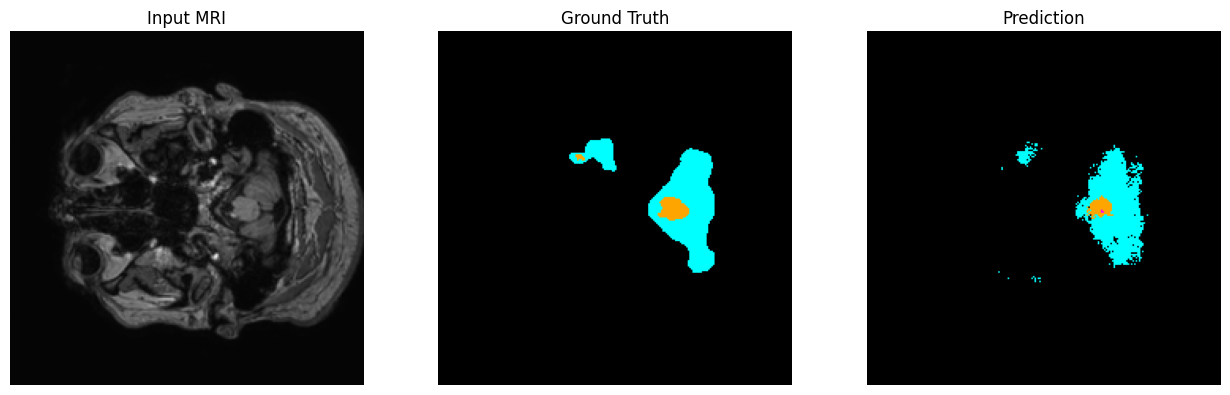

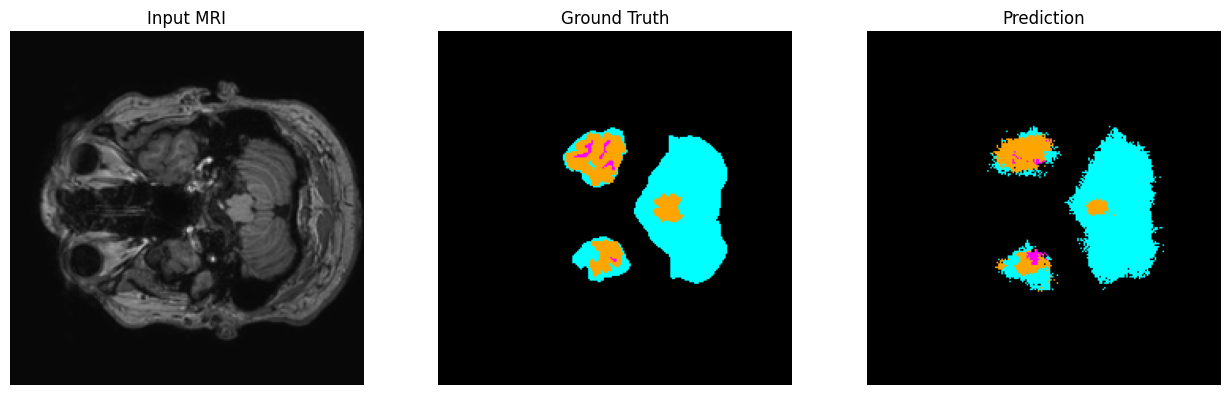

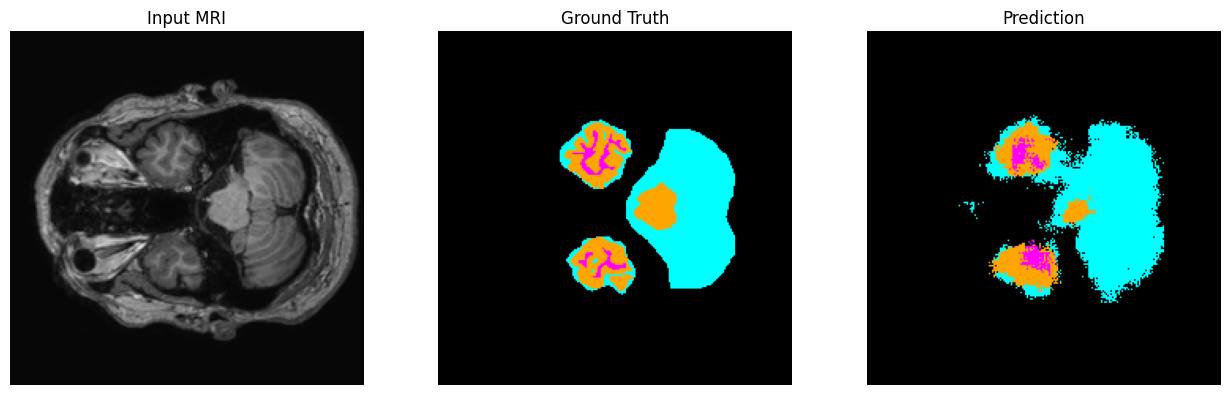

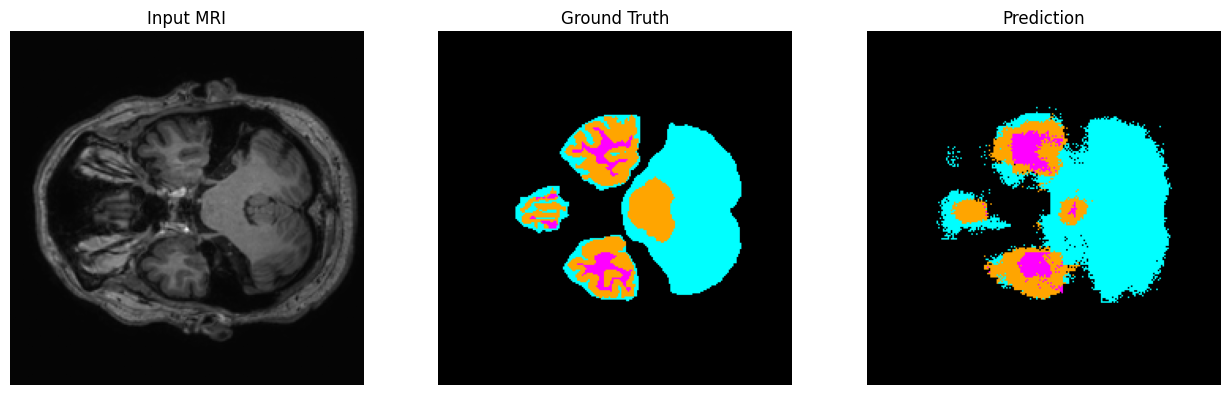

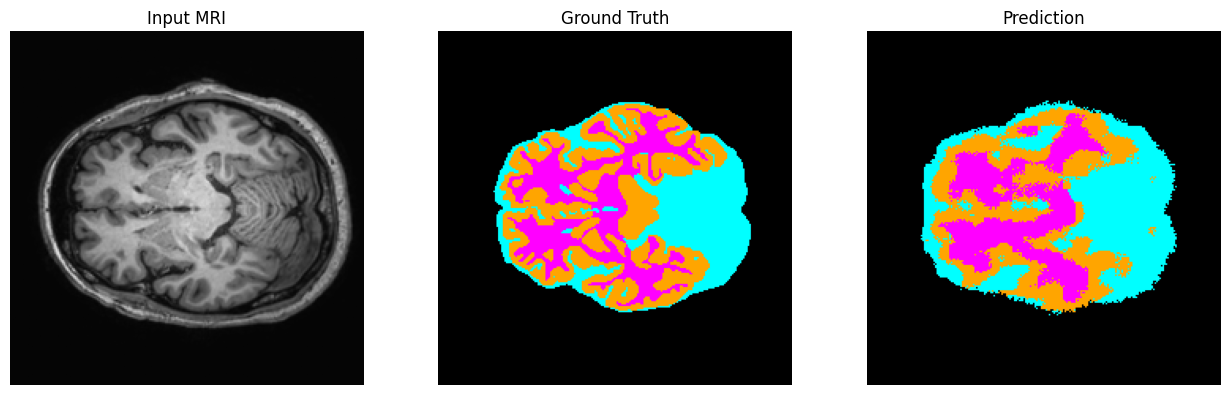

In [20]:
show_predictions(test_dataset, num=5, model_to_use=best_model)

## 17. Save Final Model

In [21]:
best_model.save('mrbrains_fcn8s_multiclass_final.keras')
print('Model saved ✓')

Model saved ✓
